## Group # 7: Prescriptive Statistical Problems Assignment Part 2

## 1. Simulation Setup and Parameters

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed for reproducibility
np.random.seed(42)

# Common distributions and constants
lifetimes = [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900]
lifetime_probs = [0.1, 0.13, 0.25, 0.13, 0.09, 0.12, 0.02, 0.06, 0.05, 0.05]
arrival_times = [20, 30, 45]
arrival_probs = [0.6, 0.3, 0.1]
repair_times = {1: 20, 2: 30, 3: 40}
repair_time_fixed = 40  # For proposed policy
fan_cost_per_unit = 32
tech_cost_per_hour = 30
downtime_cost_per_min = 10
num_cycles = 45

## 2. Current Policy Simulation

In [15]:
# --- Current Policy Simulation ---

# Start with 3 fans, each randomly assigned a lifetime
fan_lives = np.random.choice(lifetimes, size=3, p=lifetime_probs)
current_time = 0
results = []

# Run the simulation for a number of cycles
for cycle in range(1, num_cycles + 1):
    time_to_failure = min(fan_lives)
    current_time += time_to_failure

    failed_fans = sum(1 for life in fan_lives if life == time_to_failure)      # Count how many  fans failed at the same time.

    # Replace only the failed fans,  the others fans continue with reduced life
    new_lives = []
    for life in fan_lives:
        if life == time_to_failure:
            new_life = np.random.choice(lifetimes, p=lifetime_probs)
            new_lives.append(new_life)
        else:
            new_lives.append(life - time_to_failure)
    fan_lives = np.array(new_lives)

    # Random arrival time and get repair time depending on how many fans failed
    arrival_time = np.random.choice(arrival_times, p=arrival_probs)
    repair_time = repair_times[failed_fans]
    downtime = arrival_time + repair_time

  # Cost
    fan_cost = failed_fans * fan_cost_per_unit
    tech_cost = (downtime / 60) * tech_cost_per_hour
    downtime_cost = downtime * downtime_cost_per_min
    total_cost = fan_cost + tech_cost + downtime_cost

    results.append({
        'Cycle': cycle,
        'Policy': 'Current',
        'Time of Failure': current_time,
        'Fans Replaced': failed_fans,
        'Arrival (min)': arrival_time,
        'Repair Time (min)': repair_time,
        'Downtime (min)': downtime,
        'Fan Cost ($)': fan_cost,
        'Tech Cost ($)': tech_cost,
        'Downtime Cost ($)': downtime_cost,
        'Total Cost ($)': total_cost
    })

df_current = pd.DataFrame(results).set_index('Cycle')

# --- Display results Current Policy---
print("\n=== Current Policy Simulation Results ===")
print(df_current)
print(f"\nAverage Total Cost (Current Policy): ${df_current['Total Cost ($)'].mean():.2f}")


=== Current Policy Simulation Results ===
        Policy  Time of Failure  Fans Replaced  Arrival (min)  Repair Time (min)  Downtime (min)  Fan Cost ($)  Tech Cost ($)  Downtime Cost ($)  Total Cost ($)
Cycle                                                                                                                                                           
1      Current             1200              2             20                 30              50            64           25.0                500           589.0
2      Current             1700              1             20                 20              40            32           20.0                400           452.0
3      Current             2200              1             20                 20              40            32           20.0                400           452.0
4      Current             2500              1             20                 20              40            32           20.0                400        

## 3. Proposed Policy Simulation

In [16]:
# --- Proposed Policy Simulation ---

# Start with 3 new fans assigned random lifetimes
fan_lives = np.random.choice(lifetimes, size=3, p=lifetime_probs)
current_time = 0
results = []

# Run the simulation for the same numbers of cycles
for cycle in range(1, num_cycles + 1):
    time_to_failure = min(fan_lives)
    current_time += time_to_failure

    # Regardless of which fan failed, we replace   all 3 fans every time. 
    fan_lives = np.random.choice(lifetimes, size=3, p=lifetime_probs)
    fans_replaced = 3

    # fixed repair time and a random technician arrival time
    arrival_time = np.random.choice(arrival_times, p=arrival_probs)
    downtime = arrival_time + repair_time_fixed

    fan_cost = fans_replaced * fan_cost_per_unit
    tech_cost = (downtime / 60) * tech_cost_per_hour
    downtime_cost = downtime * downtime_cost_per_min
    total_cost = fan_cost + tech_cost + downtime_cost

    results.append({
        'Cycle': cycle,
        'Policy': 'Proposed',
        'Time of Failure': current_time,
        'Fans Replaced': fans_replaced,
        'Arrival (min)': arrival_time,
        'Repair Time (min)': repair_time_fixed,
        'Downtime (min)': downtime,
        'Fan Cost ($)': fan_cost,
        'Tech Cost ($)': tech_cost,
        'Downtime Cost ($)': downtime_cost,
        'Total Cost ($)': total_cost
    })

df_proposed = pd.DataFrame(results).set_index('Cycle')


In [17]:


# --- Display results Proposed Policy---
print("\n=== Proposed Policy Simulation Results ===")
print(df_proposed)
print(f"\nAverage Total Cost (Proposed Policy): ${df_proposed['Total Cost ($)'].mean():.2f}")


=== Proposed Policy Simulation Results ===
         Policy  Time of Failure  Fans Replaced  Arrival (min)  Repair Time (min)  Downtime (min)  Fan Cost ($)  Tech Cost ($)  Downtime Cost ($)  Total Cost ($)
Cycle                                                                                                                                                            
1      Proposed             1100              3             30                 40              70            96           35.0                700           831.0
2      Proposed             2500              3             30                 40              70            96           35.0                700           831.0
3      Proposed             3600              3             20                 40              60            96           30.0                600           726.0
4      Proposed             4800              3             30                 40              70            96           35.0                700 

In [10]:
pip install XlsxWriter

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 4.  Summary Table and Visualizations


=== Policy Cost Comparison Summary ===
     Policy  Average Total Cost ($)  Total Cost ($)
0   Current                  509.22         22915.0
1  Proposed                  803.00         36135.0


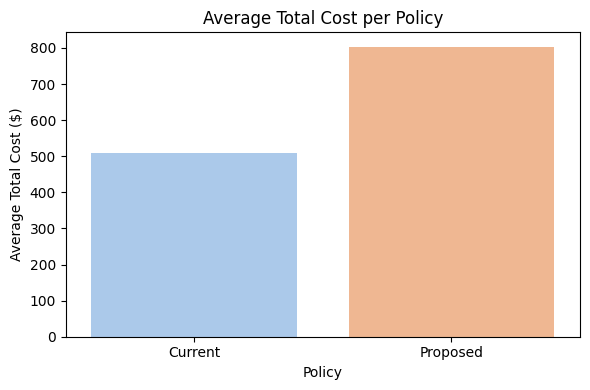

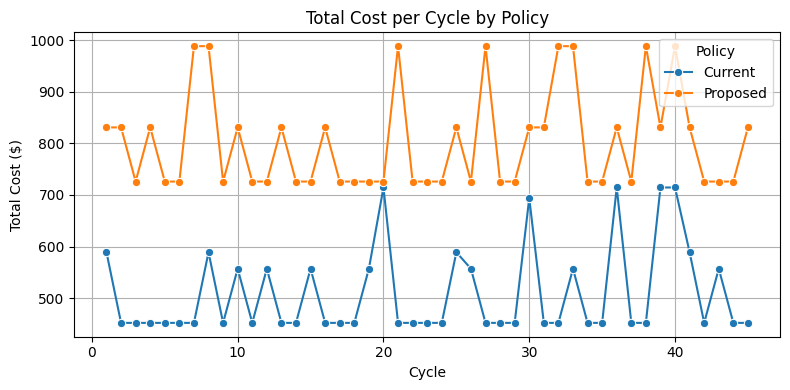

✅ Export completed successfully:
- PrescriptiveG7Assignment2_Results.xlsx
- Average_Total_Cost_Comparison.png
- Total_Cost_per_Cycle_Comparison.png


In [19]:
# Summary comparison table
summary = pd.DataFrame({
    "Policy": ["Current", "Proposed"],
    "Average Total Cost ($)": [df_current["Total Cost ($)"].mean(), df_proposed["Total Cost ($)"].mean()],
    "Total Cost ($)": [df_current["Total Cost ($)"].sum(), df_proposed["Total Cost ($)"].sum()]
})

pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)


print("\n=== Policy Cost Comparison Summary ===")
print(summary.round(2))  # Round values for cleaner output

# Calculate cost difference and percentage savings
summary["Cost Difference ($)"] = summary.loc[1, "Total Cost ($)"] - summary.loc[0, "Total Cost ($)"]
summary["% Savings vs Proposed"] = (1 - (summary.loc[0, "Total Cost ($)"] / summary.loc[1, "Total Cost ($)"])) * 100

plt.figure(figsize=(6, 4))
sns.barplot(data=summary, x='Policy', y='Average Total Cost ($)', hue='Policy', palette='pastel', legend=False)
plt.title('Average Total Cost per Policy')
plt.ylabel('Average Total Cost ($)')
plt.xlabel('Policy')
plt.tight_layout()
plt.savefig('Average_Total_Cost_Comparison.png')
plt.show()

# Visualization: Total cost per cycle for each policy
df_current_plot = df_current[['Total Cost ($)']].copy()
df_current_plot['Policy'] = 'Current'

df_proposed_plot = df_proposed[['Total Cost ($)']].copy()
df_proposed_plot['Policy'] = 'Proposed'

# Combine both datasets
df_plot = pd.concat([df_current_plot, df_proposed_plot]).reset_index()

# line plot
plt.figure(figsize=(8, 4))
sns.lineplot(data=df_plot, x='Cycle', y='Total Cost ($)', hue='Policy', marker='o')
plt.title('Total Cost per Cycle by Policy')
plt.ylabel('Total Cost ($)')
plt.xlabel('Cycle')
plt.grid(True)
plt.tight_layout()
plt.savefig('Total_Cost_per_Cycle_Comparison.png')  # Save plot as PNG
plt.show()



# Export all results to Excel file with multiple sheets
with pd.ExcelWriter("PrescriptiveG7Assignment2_Results.xlsx", engine='xlsxwriter') as writer:
    df_current.to_excel(writer, sheet_name="Current Policy", index=True)
    df_proposed.to_excel(writer, sheet_name="Proposed Policy", index=True)
    summary.to_excel(writer, sheet_name="Summary Comparison", index=False)

print("✅ Export completed successfully:")
print("- PrescriptiveG7Assignment2_Results.xlsx")
print("- Average_Total_Cost_Comparison.png")
print("- Total_Cost_per_Cycle_Comparison.png")